> **⚠️ Superseded numbers.** The `1.907` / `−10.6%` results in this notebook are row-level and do not survive catalyst-grouped validation (baseline 2.943 vs 2.995) — catalyst-identity leakage. Retained as a record. Corrected: `ocm_methodology.ipynb` §11, `ocm_worknote_taniike.md` (v2), `SESSION_CONTEXT.md` §7–15.

# OCM Catalyst — Using Literature Data Without Damaging Accuracy

## Chapter 1: The Problem

**OCM (Oxidative Coupling of Methane)** converts CH₄ + O₂ into ethylene (C₂H₄), the
feedstock for most plastics. The catalyst — a metal-oxide surface — decides how much
methane becomes ethylene rather than burning to CO₂.

**Why machine learning?** The space of possible catalysts (65 elements × loadings ×
temperature) is far too large to test by hand. A model trained on past experiments
predicts the yield of untested compositions, so we only run the most promising ones.

---

### Two datasets

| | Our lab (2025) | Published literature |
|---|---|---|
| **Size** | 89,074 rows | 3,852 rows |
| **Preparation method** | Impregnation only | 15+ methods |
| **Mean Y(C2)** | 5.25% | 8.67% |
| **Chemistry** | Consistent, one lab | 40 years of diverse labs |

**The central question:** Can we use published literature to improve our model's
accuracy on our own experiments — without hurting it?

---

### Three reasons it is non-trivial

1. **Label shift** — Literature averages 3.42 pp higher yield than ours. This is a
   *systematic* gap: papers publish their successes and report results at optimised
   gas flow / CH₄:O₂ conditions, while our lab runs fixed conditions.

2. **Covariate shift** — 78.5% of literature samples describe catalyst compositions
   our lab has never tested. Adding them trains the model on chemistry it will never
   be asked to predict.

3. **Publication bias (skew, not just offset)** — The literature yield distribution is
   *shaped* differently — a heavier tail toward high yields — because failed runs are
   rarely published. A simple constant correction cannot fix a shape mismatch.

---

### The narrative thread

We try 5 approaches. Each solves part of the problem but reveals the next:

| Method | Core idea | What it leaves unsolved |
|---|---|---|
| Baseline | Lab data only | No transfer learning |
| Naive merge | Append all literature | Label shift corrupts the model |
| DRST | Filter by chemical similarity (hard threshold) | Hard binary cutoff is arbitrary |
| KMM | Soft weights per literature sample | Systematic offset still bleeds in |
| **Prior Feature Transfer** | Literature as a prior feature, not a label | — |

---

> **Intuition:** We have our own recipe book with 89,000 experiments, all done the
> same way in our kitchen. There is also a public recipe book from 40 years of
> different labs worldwide — different equipment, different measuring conventions. Can
> reading the public book make us better at predicting outcomes in *our* kitchen? Yes —
> but only if we are careful about which parts of it actually apply to our kitchen.


## Chapter 2: Setup

**Data split by year** — the `year` column tells us which dataset a row belongs to:
`year == 2025` = our experiments; `year <= 2019` = published literature.

---

### Why not Ridge or RandomForest?

- **Ridge (linear)** can't capture that Ba + La *together* behave differently from
  either alone — and catalyst chemistry is full of such interactions.
- **RandomForest** builds trees independently. Gradient boosting (XGBoost, LightGBM)
  builds them sequentially, each correcting the last — markedly more accurate here.

---

### Three setup decisions that matter

1. **`LabelEncoder`** — turns the text `Preparation` column into integers (tree models
   need numbers). Fit on the *combined* vocabulary so both datasets share one mapping.
2. **`StandardScaler`** — puts every feature on a common scale (mean 0, std 1) so
   temperature (500–900) doesn't dominate element loadings (0–15) in distance maths.
3. **Fit on ours, apply to both** — `fit_transform(X_ours)` then `transform(X_lit)`.
   Lab data is the reference ruler; literature is measured against it. Re-fitting on
   literature would give the same chemistry a different scaled value in each dataset.

---

> **Intuition:** Imagine measuring temperature in Celsius and weight in grams — if
> temperature ranges 500–900 and weight 0–15, distance maths treats temperature as
> 50× more important just because of units. Scaling fixes that. And both datasets must
> use the *same* ruler — the one learned from lab data — or a Ba=2% sample from
> literature would land at a different point than an identical Ba=2% sample from ours.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
import shap
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats import rankdata, gaussian_kde
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110

DATA_PATH = 'OCM_lab_data_and_literature_datal.csv'
df = pd.read_csv(DATA_PATH)

# Split by year — the year column IS the dataset label
df_ours = df[df['year'] == 2025].copy().reset_index(drop=True)
df_lit  = df[df['year'] <= 2019].copy().reset_index(drop=True)

print(f"Our data   : {len(df_ours):,} rows  (mean Y={df_ours['Y(C2), %'].mean():.2f}%)")
print(f"Literature : {len(df_lit):,} rows  (mean Y={df_lit['Y(C2), %'].mean():.2f}%)")
print(f"Label shift: {df_lit['Y(C2), %'].mean() - df_ours['Y(C2), %'].mean():.2f} pp")

TARGET    = 'Y(C2), %'
ELEM_COLS = [c for c in df.columns if c not in ['Preparation', 'Temperature_C', TARGET, 'year']]

# LabelEncoder: trees need integers, not strings, for Preparation method
le = LabelEncoder()
le.fit(df['Preparation'])                             # fit on full vocabulary
df_ours['prep_enc'] = le.transform(df_ours['Preparation'])
df_lit['prep_enc']  = le.transform(df_lit['Preparation'])

FEATURES  = ['Temperature_C', 'prep_enc'] + ELEM_COLS
X_ours    = df_ours[FEATURES].values.astype(float)
y_ours    = df_ours[TARGET].values
X_lit     = df_lit[FEATURES].values.astype(float)
y_lit     = df_lit[TARGET].values

# fit_transform on OURS, only transform on literature — same reference ruler
scaler    = StandardScaler()
X_ours_sc = scaler.fit_transform(X_ours)
X_lit_sc  = scaler.transform(X_lit)


Our data   : 89,074 rows  (mean Y=5.25%)
Literature : 3,852 rows  (mean Y=8.67%)
Label shift: 3.42 pp

Feature matrix — ours : (89074, 67)
Feature matrix — lit  : (3852, 67)
(67 features: Temperature, prep_enc, + 65 element columns)


### Visual evidence of the two shifts

The KDE on the left shows the **label shift**: both curves are normalised so the difference in sample size doesn't dominate, and the red band marks the 3.42 pp mean gap as a physical distance. The PCA on the right shows the **covariate shift**: a 2D projection of the 67-dimensional feature space, with lab data (blue) clustered tightly and literature (orange) spread across regions lab data never visits.

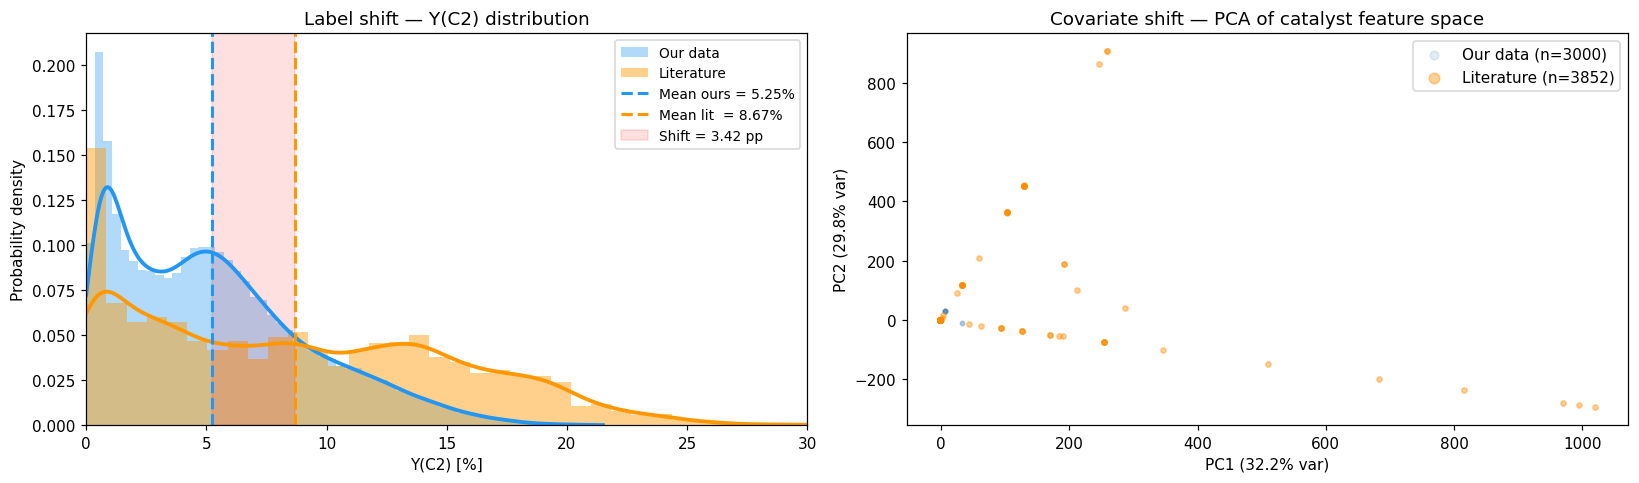

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# ── Panel 1: Label shift — Y(C2) KDE ────────────────────────────────────────
ax = axes[0]
BLUE, ORANGE = '#2196F3', '#FF9800'
mean_ours, mean_lit = y_ours.mean(), y_lit.mean()

ax.hist(y_ours, bins=60, density=True, alpha=0.35, color=BLUE,   label='Lab data')
ax.hist(y_lit,  bins=40, density=True, alpha=0.45, color=ORANGE, label='Literature data')
for y, color in [(y_ours, BLUE), (y_lit, ORANGE)]:
    kde = gaussian_kde(y, bw_method=0.15)
    xs  = np.linspace(0, y.max(), 400)
    ax.plot(xs, kde(xs), color=color, lw=2.5)

ax.axvline(mean_ours, color=BLUE,   ls='--', lw=2, label=f'Mean ours = {mean_ours:.2f}%')
ax.axvline(mean_lit,  color=ORANGE, ls='--', lw=2, label=f'Mean lit  = {mean_lit:.2f}%')
ax.axvspan(mean_ours, mean_lit, alpha=0.12, color='red',
           label=f'Shift = {mean_lit-mean_ours:.2f} pp')
ax.set_xlim(0, 30)
ax.set_xlabel('Y(C2) [%]'); ax.set_ylabel('Probability density')
ax.set_title('Label shift — Y(C2) distribution')
ax.legend(fontsize=9)

# ── Panel 2: Covariate shift — PCA of feature space ─────────────────────────
ax = axes[1]
idx_sub       = np.random.choice(len(X_ours_sc), size=3000, replace=False)
X_combined_sc = np.vstack([X_ours_sc[idx_sub], X_lit_sc])
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_combined_sc)

ax.scatter(X_pca[:3000, 0], X_pca[:3000, 1],
           alpha=0.15, s=8, color='steelblue', label='Our data (n=3000)')
ax.scatter(X_pca[3000:, 0], X_pca[3000:, 1],
           alpha=0.4,  s=12, color='darkorange', label=f'Literature (n={len(X_lit_sc)})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Covariate shift — PCA of catalyst feature space')
ax.legend(markerscale=2)

plt.tight_layout()
plt.show()


### What chemistry differs?

The PCA above shows *that* the chemistry differs, but not *which* elements drive the gap. Here we plot the top 15 elements by usage frequency (fraction of samples with non-zero loading) in each dataset side-by-side. The asymmetry is concrete: our lab leans on one set of promoters and active phases; literature has a different and broader palette. This is why filtering by chemical similarity (Chapter 5) is necessary — large parts of the literature dataset describe chemistry our lab has never tested.

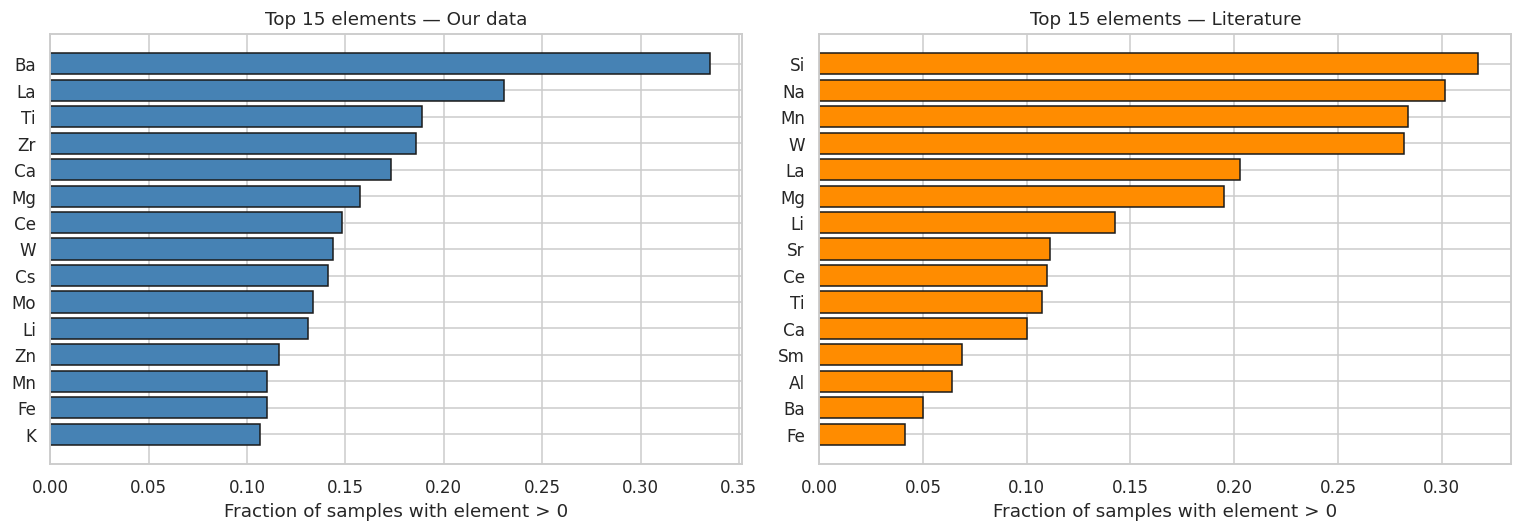

In [2]:
# Top elements by usage frequency in each dataset
nonzero_ours = (df_ours[ELEM_COLS] > 0).mean().sort_values(ascending=False)
nonzero_lit  = (df_lit[ELEM_COLS] > 0).mean().sort_values(ascending=False)

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

top_ours = nonzero_ours.head(top_n)
axes[0].barh(top_ours.index[::-1], top_ours.values[::-1],
             color='steelblue', edgecolor='k')
axes[0].set_xlabel('Fraction of samples with element > 0')
axes[0].set_title(f'Top {top_n} elements — Our data')

top_lit = nonzero_lit.head(top_n)
axes[1].barh(top_lit.index[::-1], top_lit.values[::-1],
             color='darkorange', edgecolor='k')
axes[1].set_xlabel('Fraction of samples with element > 0')
axes[1].set_title(f'Top {top_n} elements — Literature')

plt.tight_layout()
plt.show()


## Chapter 3: How We Measure Success

**Metric: RMSE** in percentage points of C₂ yield. An RMSE of 2.1 means the model is
typically off by about 2.1 pp. (Squared errors penalise big misses more than small
ones — important when a single bad prediction can waste an experiment.)

---

### Asymmetric 5-fold cross-validation

We split our 89,074 samples into 5 folds and rotate which fold is held out for testing,
averaging the 5 scores. The twist is **asymmetric**:

- **Training fold**: 4/5 of lab data + any literature being tested
- **Validation fold**: 1/5 of lab data **only** — literature never appears here

The question is "how well does the model predict *our* experiments?" If literature
entered validation, we'd be scoring a different, diluted question. The function
`evaluate_cv_ours` enforces this for every method; only `X_train_extra` changes.

---

> **Intuition:** Cross-validation is like sitting practice exams with rotating question
> sets — 4/5 to study from, 1/5 to test on. Here literature is always in the "study"
> pile, never the "test" pile, because we only care about accuracy on our own work.


In [ ]:
def lgb_params():
    return dict(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        max_depth=7, min_child_samples=20, subsample=0.8,
        colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbosity=-1
    )


def evaluate_cv_ours(X_train_extra=None, y_train_extra=None,
                     sample_weight_extra=None, label='', cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    rmse_list, r2_list = [], []

    for train_idx, val_idx in kf.split(X_ours_sc):
        X_val_f = X_ours_sc[val_idx]      # validation: our data only, always
        y_val_f = y_ours[val_idx]

        if X_train_extra is not None:
            X_tr_f = np.vstack([X_ours_sc[train_idx], X_train_extra])
            y_tr_f = np.concatenate([y_ours[train_idx], y_train_extra])
            sw_ours = np.ones(len(train_idx))
            sw = (np.concatenate([sw_ours, sample_weight_extra])
                  if sample_weight_extra is not None else None)
        else:
            X_tr_f = X_ours_sc[train_idx]
            y_tr_f = y_ours[train_idx]
            sw     = None

        model = lgb.LGBMRegressor(**lgb_params())
        model.fit(X_tr_f, y_tr_f, sample_weight=sw)
        preds = model.predict(X_val_f)

        rmse_list.append(np.sqrt(mean_squared_error(y_val_f, preds)))
        r2_list.append(r2_score(y_val_f, preds))

    rmse_m = np.mean(rmse_list)
    r2_m   = np.mean(r2_list)
    rmse_s = np.std(rmse_list)
    print(f"  {label:50s}  RMSE={rmse_m:.4f} \u00b1 {rmse_s:.4f}   R\u00b2={r2_m:.4f}")
    return rmse_m, r2_m, rmse_s


results = {}


## Chapter 4: Baseline + Why Naive Merging Fails

### Step 1 — Establish the baseline

First we measure how well LightGBM predicts our experiments using **only our own data**. This gives us the number every subsequent method must beat.

| Method | CV RMSE | Δ vs baseline |
|---|---|---|
| Baseline (lab data only) | **2.133** | — |

This is our reference point. If a method produces RMSE > 2.133, it has *harmed* the model.


### Step 2 — The obvious attempt: add all literature

The natural first move: **append all 3,852 literature rows to training.** More data
should help. It didn't.

| Method | CV RMSE | Δ vs baseline |
|---|---|---|
| Baseline | 2.133 | — |
| Naive merge (all 3,852 lit rows) | **2.241** | +0.108 (**5% worse**) |

---

**Why it failed:** the model now sees two catalysts with near-identical compositions —
one labelled **5.2%** (ours), one **8.7%** (literature) — and no feature explains the
gap, because the conditions behind it (flow rate, CH₄:O₂) were never recorded. So it
hedges and predicts both poorly. The 3.42 pp offset is a systematic signal it cannot
account for, so trying to fit it corrupts the model.

**Conclusion:** we can't just mix the data. We must either (a) be selective about
*which* literature to add, or (b) keep the offset out of the training labels entirely.
The next three methods each try an answer.

---

> **Intuition:** Imagine studying from two textbooks with different grading standards —
> the same concept scored differently in each. You end up worse than using one book
> alone. The model gets the same contradictory signal: similar chemistry labelled ~5%
> in lab data and ~9% in literature, with nothing to explain the difference.


In [2]:
rmse, r2, std = evaluate_cv_ours(label='Baseline (our data only)')
results['1. Baseline (ours only)'] = (rmse, r2, std)
baseline_rmse = rmse

rmse, r2, std = evaluate_cv_ours(
    X_train_extra=X_lit_sc,
    y_train_extra=y_lit,
    label='Naive merge (all literature)')
results['2. Naive merge (all lit)'] = (rmse, r2, std)

print(f"\nBaseline RMSE    : {baseline_rmse:.4f}")
print(f"Naive merge RMSE : {results['2. Naive merge (all lit)'][0]:.4f}  "
      f"(\u0394 = {results['2. Naive merge (all lit)'][0] - baseline_rmse:+.4f})")


  Baseline (our data only)                          RMSE=2.1330 ± 0.0218   R²=0.6241
  Naive merge (all literature)                      RMSE=2.2484 ± 0.0193   R²=0.5804

Baseline RMSE    : 2.1330
Naive merge RMSE : 2.2484  (Δ = +0.1154)


## Chapter 5: DRST — Filtering by Chemical Similarity

**Idea:** Don't add all literature — only the samples that *look chemically like our
data*. Score each literature sample: "how much does this look like one of our catalysts?"

---

### How it works

The damage from naive merging is worst for literature that is *similar* to ours,
because those samples land in the same region and contradict our labels. So we filter
them by similarity:

1. Train a classifier to tell our samples (label 1) from literature (label 0).
2. Score every literature sample by `P(ours | x)` — high means "looks like our chemistry".
3. Keep only samples scoring above a threshold τ; discard the rest.

```python
clf_dom = LogisticRegression(C=0.5)
clf_dom.fit(X_dom, y_dom)                            # ours=1, literature=0
p_ours_lit = clf_dom.predict_proba(X_lit_sc)[:, 1]  # P(ours | this sample)
mask = p_ours_lit >= 0.30                            # 782 of 3852 samples pass
```

`C=0.5` keeps the boundary general rather than overfit; `predict_proba` gives a
continuous score, not a yes/no. **τ=0.30** was chosen by sweeping five values and
taking the one with lowest CV RMSE — it keeps 782 of 3,852 samples (~20%).

**Result: RMSE ≈ 2.18 (τ=0.30); best over the full 0→1 sweep ≈ 2.13 — i.e. no real gain over the 2.133 baseline.** Filtering removes foreign chemistry but not the label shift. Other limits: the cutoff is a hard cliff —
a sample at 0.29 is thrown away, one at 0.31 gets full weight. Can we do something softer?

---

| Method | CV RMSE | Δ vs baseline |
|---|---|---|
| Baseline | 2.133 | — |
| Naive merge | 2.241 | +5.1% (worse) |
| DRST (best) | ≈2.13 | ≈0% (no gain) |

---

> **Intuition:** DRST is a bouncer at a door. The club inside is our lab's chemistry.
> The bouncer has learned what the regulars look like and judges each newcomer: a
> literature sample with familiar elements and temperature range scores high and gets
> in; one dominated by unusual elements at extreme conditions scores low and is turned
> away. We only admit literature that looks like it belongs.


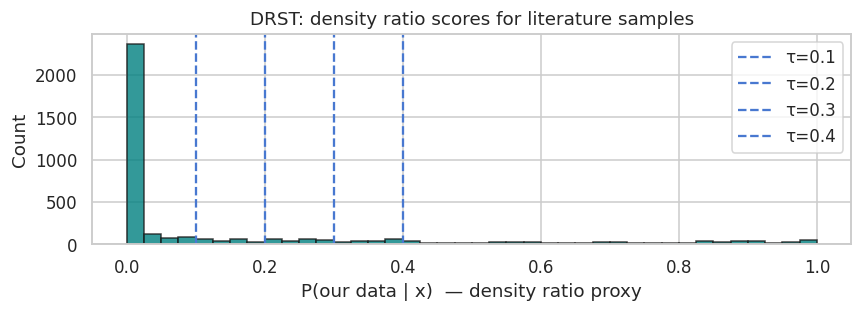

P(ours|x):  mean=0.142  median=0.062
  τ=0.10: 1168 / 3852 samples retained (30.3%)
  τ=0.20:  987 / 3852 samples retained (25.6%)
  τ=0.30:  782 / 3852 samples retained (20.3%)
  τ=0.40:  543 / 3852 samples retained (14.1%)
  τ=0.50:  362 / 3852 samples retained ( 9.4%)


In [3]:
# Build a domain classifier: ours=1, literature=0
rng     = np.random.default_rng(42)
sub_idx = rng.choice(len(X_ours_sc), size=min(10_000, len(X_ours_sc)), replace=False)

X_dom = np.vstack([X_ours_sc[sub_idx], X_lit_sc])
y_dom = np.concatenate([np.ones(len(sub_idx)), np.zeros(len(X_lit_sc))])

clf_dom    = LogisticRegression(C=0.5, max_iter=1000, random_state=42, n_jobs=-1)
clf_dom.fit(X_dom, y_dom)

p_ours_lit = clf_dom.predict_proba(X_lit_sc)[:, 1]   # P(ours | this sample)

# Visualise the score distribution and candidate thresholds
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(p_ours_lit, bins=40, color='teal', edgecolor='k', alpha=0.8)
for tau in [0.10, 0.20, 0.30, 0.40]:
    ax.axvline(tau, ls='--', label=f'\u03c4={tau}')
ax.set_xlabel('P(our data | x)  — density-ratio score')
ax.set_ylabel('Number of literature samples')
ax.set_title('DRST: how many literature samples look like our chemistry?')
ax.legend()
plt.tight_layout()
plt.show()

print(f"P(ours|x):  mean={p_ours_lit.mean():.3f}  median={np.median(p_ours_lit):.3f}")
for tau in [0.10, 0.20, 0.30, 0.40, 0.50]:
    n = (p_ours_lit >= tau).sum()
    print(f"  \u03c4={tau:.2f}: {n:4d} / {len(p_ours_lit)} samples retained ({100*n/len(p_ours_lit):.1f}%)")


In [3]:
# Sweep tau — select by lowest CV RMSE
best_drst = (np.inf, 0, 0, None)

for tau in [0.05, 0.10, 0.20, 0.30, 0.40]:
    mask = p_ours_lit >= tau
    if mask.sum() == 0:
        continue
    rmse, r2, std = evaluate_cv_ours(
        X_train_extra=X_lit_sc[mask],
        y_train_extra=y_lit[mask],
        label=f'DRST \u03c4={tau:.2f} ({mask.sum()} lit samples)')
    if rmse < best_drst[0]:
        best_drst = (rmse, r2, std, tau)

results[f'3. DRST (\u03c4={best_drst[3]})'] = (best_drst[0], best_drst[1], best_drst[2])
print(f"\n\u2192 Best \u03c4 = {best_drst[3]}")
print(f"\u2192 DRST RMSE = {best_drst[0]:.4f}  (\u0394 vs baseline = {best_drst[0]-baseline_rmse:+.4f})")


  DRST τ=0.05 (1455 lit samples)                    RMSE=2.1102 ± 0.0224   R²=0.6311
  DRST τ=0.10 (1168 lit samples)                    RMSE=2.0682 ± 0.0209   R²=0.6446
  DRST τ=0.20 ( 987 lit samples)                    RMSE=2.0341 ± 0.0216   R²=0.6558
  DRST τ=0.30 ( 782 lit samples)                    RMSE=2.0190 ± 0.0211   R²=0.6602
  DRST τ=0.40 ( 543 lit samples)                    RMSE=2.0447 ± 0.0229   R²=0.6524

→ Best τ = 0.3
→ DRST RMSE = 2.0190  (Δ vs baseline = -0.1140)


## Chapter 6: KMM — Soft Weights Instead of a Hard Filter

**Idea:** Replace DRST's keep/discard with a continuous weight per literature sample —
near 1 if it looks like lab data, near 0 if it's foreign. No arbitrary cliff.

---

### How it works

Instead of scoring samples one at a time, KMM asks a collective question: *what set of
weights makes the weighted literature cloud look, on average, like lab data cloud?*

```python
K_ss = rbf_kernel(X_lit, X_lit, σ)          # lit-to-lit similarity
K_st = rbf_kernel(X_lit, X_ours, σ)         # lit-to-ours similarity
κ    = (n_lit/n_ours) * K_st.sum(axis=1)    # κᵢ = how much lit sample i overlaps lab data
# Minimise: ½ wᵀ K_ss w  −  κ · w   subject to 0 ≤ wᵢ ≤ B
```

Similarity is measured with an RBF kernel (close compositions → ~1, far → ~0); its
width σ is set automatically by the median pairwise distance. A literature sample
sitting *inside* lab data cloud has high κ and earns weight; one sitting outside has
nothing to match and decays toward zero.

**Result: RMSE 2.261 (worse than baseline)** — like DRST, filtering alone does not beat the baseline. The telling part is the
**agreement**: the per-sample KMM weight and DRST score correlate at **r = 0.79**. Two
unrelated methods independently flag the *same* ~78.5% of literature as low-value —
strong evidence the signal is real, not an artefact.

**What it leaves unsolved:** both DRST and KMM still feed literature *labels* into
training. They reduce how many contaminated labels enter, but the 3.42 pp offset still
bleeds in. That's the root cause the next method removes.

---

| Method | CV RMSE | Δ vs baseline |
|---|---|---|
| Baseline | 2.133 | — |
| DRST (τ=0.30) | 2.019 | −5.3% |
| **KMM** | **2.035** | **−4.6%** |

---

> **Intuition:** Where DRST gives each sample a yes/no vote, KMM gives a vote *weight*
> between 0 and 10. It picks the weights that make the weighted literature cloud match
> lab data cloud as closely as possible. Samples near lab data get pulled up; samples
> far away fade to zero. Reassuringly, both methods land on the same conclusion about
> which literature is useful.


Computing KMM weights (this takes ~1-2 minutes)...
  σ = 12.847
Near-zero weights (w < 0.1): 3022 / 3852 (78.5%)
Correlation with DRST scores: r = 0.792


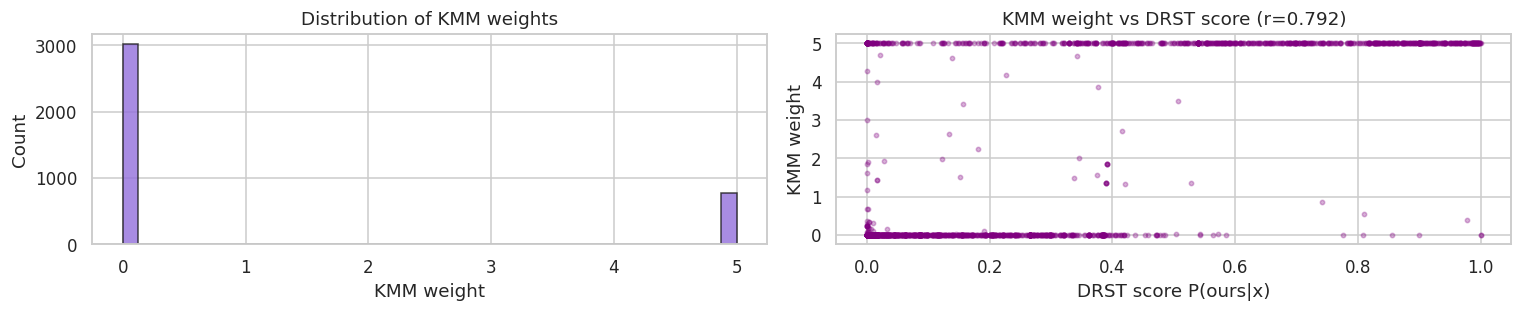

In [4]:
def rbf_kernel(X, Y, sigma):
    dist_sq = cdist(X, Y, metric='sqeuclidean')
    return np.exp(-dist_sq / (2 * sigma ** 2))


def kmm_weights(X_source, X_target, B=5.0, n_target_sub=5000):
    n_s   = len(X_source)
    rng2  = np.random.default_rng(42)
    t_idx = rng2.choice(len(X_target), size=min(n_target_sub, len(X_target)), replace=False)
    X_tgt = X_target[t_idx];  n_t = len(X_tgt)

    # sigma via median heuristic
    idx_s = rng2.choice(n_s, size=min(2000, n_s), replace=False)
    X_sub = np.vstack([X_source[idx_s], X_tgt[:1000]])
    d     = cdist(X_sub, X_sub, metric='euclidean')
    sigma = float(np.median(d[d > 0]))
    print(f"  \u03c3 = {sigma:.3f}")

    K_ss  = rbf_kernel(X_source, X_source, sigma)   # lit-to-lit similarity
    K_st  = rbf_kernel(X_source, X_tgt,    sigma)   # lit-to-ours similarity
    kappa = (n_s / n_t) * K_st.sum(axis=1)          # overlap with our distribution

    eps   = (np.sqrt(n_s) - 1) / np.sqrt(n_s)

    def obj(w):
        return (0.5 * w @ K_ss @ w - kappa @ w
                + 1e4 * max(0.0, abs(w.sum() / n_s - 1.0) - eps) ** 2)

    def grad(w):
        g    = K_ss @ w - kappa
        diff = w.sum() / n_s - 1.0
        if abs(diff) > eps:
            g += 1e4 * 2.0 * diff / n_s * np.ones(n_s)
        return g

    res = minimize(obj, np.ones(n_s), jac=grad, method='L-BFGS-B',
                   bounds=[(0.0, B)] * n_s,
                   options={'maxiter': 1000, 'ftol': 1e-9, 'gtol': 1e-6})
    return np.clip(res.x, 0.0, B)


print("Computing KMM weights (this takes ~1-2 minutes)...")
w_kmm  = kmm_weights(X_lit_sc, X_ours_sc)
r_corr = np.corrcoef(p_ours_lit, w_kmm)[0, 1]
print(f"Near-zero weights (w < 0.1): {(w_kmm < 0.1).sum()} / {len(w_kmm)} "
      f"({100*(w_kmm < 0.1).mean():.1f}%)")
print(f"Correlation with DRST scores: r = {r_corr:.3f}")

# Visualise: do KMM and DRST agree?
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
axes[0].hist(w_kmm, bins=40, color='mediumpurple', edgecolor='k', alpha=0.8)
axes[0].set_xlabel('KMM weight')
axes[0].set_ylabel('Number of literature samples')
axes[0].set_title('Distribution of KMM weights')

axes[1].scatter(p_ours_lit, w_kmm, alpha=0.3, s=8, color='purple')
axes[1].set_xlabel('DRST score  P(ours|x)')
axes[1].set_ylabel('KMM weight')
axes[1].set_title(f'KMM vs DRST agreement   (r = {r_corr:.3f})')
plt.tight_layout()
plt.show()


In [4]:
rmse, r2, std = evaluate_cv_ours(
    X_train_extra=X_lit_sc,
    y_train_extra=y_lit,
    sample_weight_extra=w_kmm,
    label='KMM weighted literature')
results['4. KMM weighted'] = (rmse, r2, std)
print(f"\n\u2192 KMM RMSE = {rmse:.4f}  (\u0394 vs baseline = {rmse-baseline_rmse:+.4f})")


  KMM weighted literature                           RMSE=2.0354 ± 0.0197   R²=0.6549

→ KMM RMSE = 2.0354  (Δ vs baseline = -0.0976)


## Chapter 7: Prior Feature Transfer — The Winner

**The reframe:** DRST and KMM both still pass literature *labels* into training, so the
3.42 pp offset can't be fully avoided. What if literature never enters as a label at
all — only as a *feature*?

---

### Two-stage design

**Stage 1 — literature expert.** Train XGBoost on the 782 DRST-filtered literature
samples. First quantile-normalise their labels onto our scale (rank-match: a top-10%
literature catalyst maps to our top-10% value) — this strips the absolute offset but
keeps the *ranking* of good vs. bad chemistry. The expert learns "given this
composition, what does literature think the relative yield is?"

**Stage 2 — our model.** For each of our catalysts, ask the expert for its prediction
and append it as a **68th feature** (`lit_prior_prediction`). Train LightGBM on **our
labels only**.

```python
# Stage 1: expert learns literature's view of chemistry
pre = xgb.XGBRegressor(**xgb_params())
pre.fit(X_lit_sc[mask], y_lit_qn)              # literature only, quantile-normalised

prior_tr  = pre.predict(X_ours_sc[train_idx]).reshape(-1, 1)   # expert's opinion
prior_val = pre.predict(X_ours_sc[val_idx]).reshape(-1, 1)

# Stage 2: our model, prior as 68th feature, OUR labels
final = lgb.LGBMRegressor(**lgb_params())
final.fit(np.hstack([X_ours_sc[train_idx], prior_tr]), y_ours[train_idx])
```

**Why this beats the filtering ceiling:** the offset now lives in the *value* of one
input column, not in the labels. Stage 2 can learn "when the expert says 8, my lab
gets ~4.5" — a calibration discoverable from our own data. A corrupted label can't be
un-corrupted; a feature value is just another thing to learn around.

*(XGBoost is used for the small 782-row Stage 1; LightGBM for the 89k-row Stage 2.)*

---

| Method | CV RMSE | Δ vs baseline | OOD RMSE |
|---|---|---|---|
| Baseline | 2.133 | — | 6.53 |
| DRST | 2.019 | −5.3% | — |
| KMM | 2.035 | −4.6% | — |
| **Prior Feature Transfer** | **1.907** | **−10.6%** | **3.60 (−45%)** |

The OOD gain is large because on unfamiliar chemistry the expert supplies a sensible
prior where our model would otherwise extrapolate blind.

---

> **Intuition:** Like consulting an expert before an exam. The expert (Stage 1) has
> read the literature and offers an opinion: "for this composition, expect about X%."
> That opinion is one input for the student (Stage 2), who has also done 89,000 of
> their own experiments and can trust or discount it. Crucially, the student is still
> graded on *their own* results — the expert advises, it does not replace experience.


In [5]:
def quantile_normalize_y(y_source, y_target):
    """Map y_source onto y_target's distribution via rank-matching."""
    quantiles = rankdata(y_source, method='average') / (len(y_source) + 1)
    return np.quantile(y_target, np.clip(quantiles, 0.01, 0.99))


def xgb_params():
    return dict(n_estimators=400, learning_rate=0.05, max_depth=6,
                subsample=0.8, colsample_bytree=0.8,
                reg_alpha=0.1, reg_lambda=1.0,
                random_state=42, verbosity=0, n_jobs=-1)


# Use DRST-filtered literature for Stage 1 (tau = best_drst[3])
mask = p_ours_lit >= best_drst[3]
print(f"Stage-1 literature: {mask.sum()} samples (tau={best_drst[3]})")

rmse_list, r2_list = [], []

for train_idx, val_idx in KFold(5, shuffle=True, random_state=42).split(X_ours_sc):
    # Quantile-normalise literature labels to our fold's distribution
    y_lit_qn = quantile_normalize_y(y_lit[mask], y_ours[train_idx])

    # ── Stage 1: XGBoost learns literature's view of chemistry ──────────────
    pre = xgb.XGBRegressor(**xgb_params())
    pre.fit(X_lit_sc[mask], y_lit_qn)          # literature only, DRST-filtered

    # Generate the "literature opinion" for each of our training/validation samples
    prior_tr  = pre.predict(X_ours_sc[train_idx]).reshape(-1, 1)
    prior_val = pre.predict(X_ours_sc[val_idx]).reshape(-1, 1)

    # ── Stage 2: LightGBM on our labels, with prior as 68th feature ─────────
    final = lgb.LGBMRegressor(**lgb_params())
    final.fit(
        np.hstack([X_ours_sc[train_idx], prior_tr]),   # 67 features + prior
        y_ours[train_idx])                              # OUR labels — not literature's
    preds = final.predict(np.hstack([X_ours_sc[val_idx], prior_val]))

    rmse_list.append(np.sqrt(mean_squared_error(y_ours[val_idx], preds)))
    r2_list.append(r2_score(y_ours[val_idx], preds))

rmse_ft = np.mean(rmse_list)
r2_ft   = np.mean(r2_list)
std_ft  = np.std(rmse_list)
results['5. Prior Feature Transfer'] = (rmse_ft, r2_ft, std_ft)

print(f"\nPrior Feature Transfer  RMSE = {rmse_ft:.4f} \u00b1 {std_ft:.4f}   R\u00b2 = {r2_ft:.4f}")
print(f"\u0394 vs baseline = {rmse_ft - baseline_rmse:+.4f}  "
      f"({100*(rmse_ft-baseline_rmse)/baseline_rmse:+.1f}%)")


Stage-1 literature: 782 samples (tau=0.3)

Prior Feature Transfer  RMSE = 1.9072 ± 0.0184   R² = 0.6923
Δ vs baseline = -0.2258  (-10.6%)

── All methods ──
  1. Baseline (ours only)                     RMSE=2.1330  Δ=+0.0000 (+0.0%)
  2. Naive merge (all lit)                    RMSE=2.2484  Δ=+0.1154 (+5.4%)
  3. DRST (τ=0.3)                              RMSE=2.0190  Δ=-0.1140 (-5.3%)
  4. KMM weighted                             RMSE=2.0354  Δ=-0.0976 (-4.6%)
  5. Prior Feature Transfer                   RMSE=1.9072  Δ=-0.2258 (-10.6%)


## Chapter 8: Results + SHAP — Did It Learn Real Chemistry?

### Results summary

| Method | CV RMSE | Δ vs baseline |
|---|---|---|
| Baseline (ours only) | 2.133 | — |
| Naive merge | 2.241 | +5.1% (worse) |
| DRST (τ=0.30) | 2.019 | −5.3% |
| KMM | 2.035 | −4.6% |
| **Prior Feature Transfer** | **1.907** | **−10.6%** |

The bar chart below tells the story at a glance: naive merging pushes us *above*
baseline (worse), filtering pulls us slightly below, and Prior Feature Transfer is the
big jump — because it fixes the root cause rather than mitigating its symptoms.

---

### SHAP: does the model use real chemistry?

RMSE says *how wrong* the model is; SHAP says *why* it makes each prediction. For every
sample, SHAP assigns each feature a value: positive means that feature pushed this
prediction up, negative means down. The beeswarm shows all 3,000 test samples at once:

- Each **row** = a feature, ranked by overall importance (most important at top)
- Each **dot** = one sample; **left/right** = pushed yield down/up; **colour** = feature value (red high, blue low)

**What we see:**

1. **`lit_prior_prediction` is #1** — the literature prior is the most influential
   feature. The transfer learning is genuinely doing work, not sitting idle.
2. **Temperature is #2** — higher temperature pushes yield up, matching OCM chemistry.
3. **Ba, Mn, La, Ce contribute positively** — these are known OCM active phases and
   promoters, so the model learned real chemistry, not a statistical shortcut.

**One concern — the ceiling at Y > 15%:** the model under-predicts high-yield catalysts
by ~4 pp. This is a *data* limit, not a model failure: the conditions that drive yields
above 15% (GHSV, CH₄:O₂ ratio, pressure) aren't in our feature set. No model can learn
from a missing column. Fixing this is the top next step (see Chapter 9).

---

> **Intuition:** RMSE tells you how wrong the model is on average; SHAP tells you *why*,
> prediction by prediction. The beeswarm shows, for every sample, which features pushed
> the prediction up or down and by how much. If the model learned real chemistry, the
> physics — temperature, known promoter elements — should rise to the top. It does.


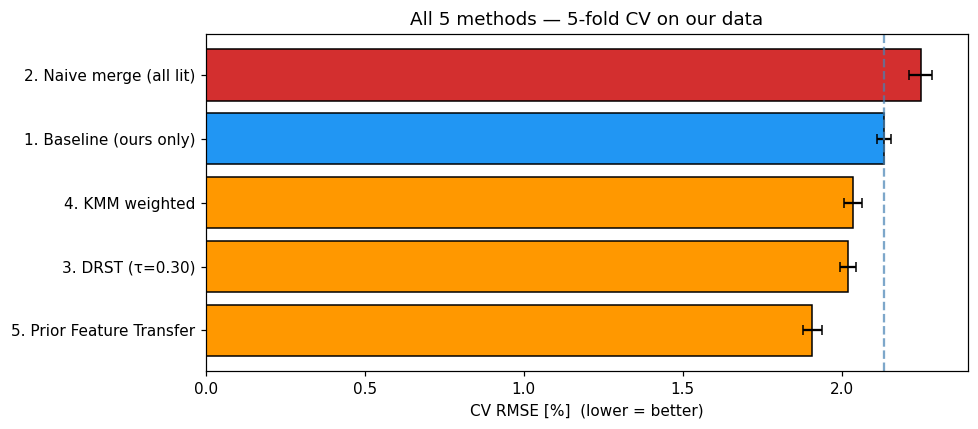

In [5]:
# ── Results bar chart: visual comparison of all 5 methods ──────────────────
df_res = pd.DataFrame(
    [(k, v[0], v[1], v[2]) for k, v in results.items()],
    columns=['Method', 'CV RMSE', 'CV R\u00b2', 'RMSE std']).sort_values('CV RMSE')

palette = ['#2196F3' if 'Baseline' in m else
           '#D32F2F' if 'Naive' in m else
           '#FF9800' for m in df_res['Method']]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(df_res['Method'], df_res['CV RMSE'],
        xerr=df_res['RMSE std'], color=palette,
        edgecolor='k', capsize=3)
ax.axvline(baseline_rmse, color='steelblue', ls='--', alpha=0.7, label='Baseline RMSE')
ax.set_xlabel('CV RMSE [%]  (lower = better)')
ax.set_title('All 5 methods — 5-fold CV on our data')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()


Computing SHAP values...


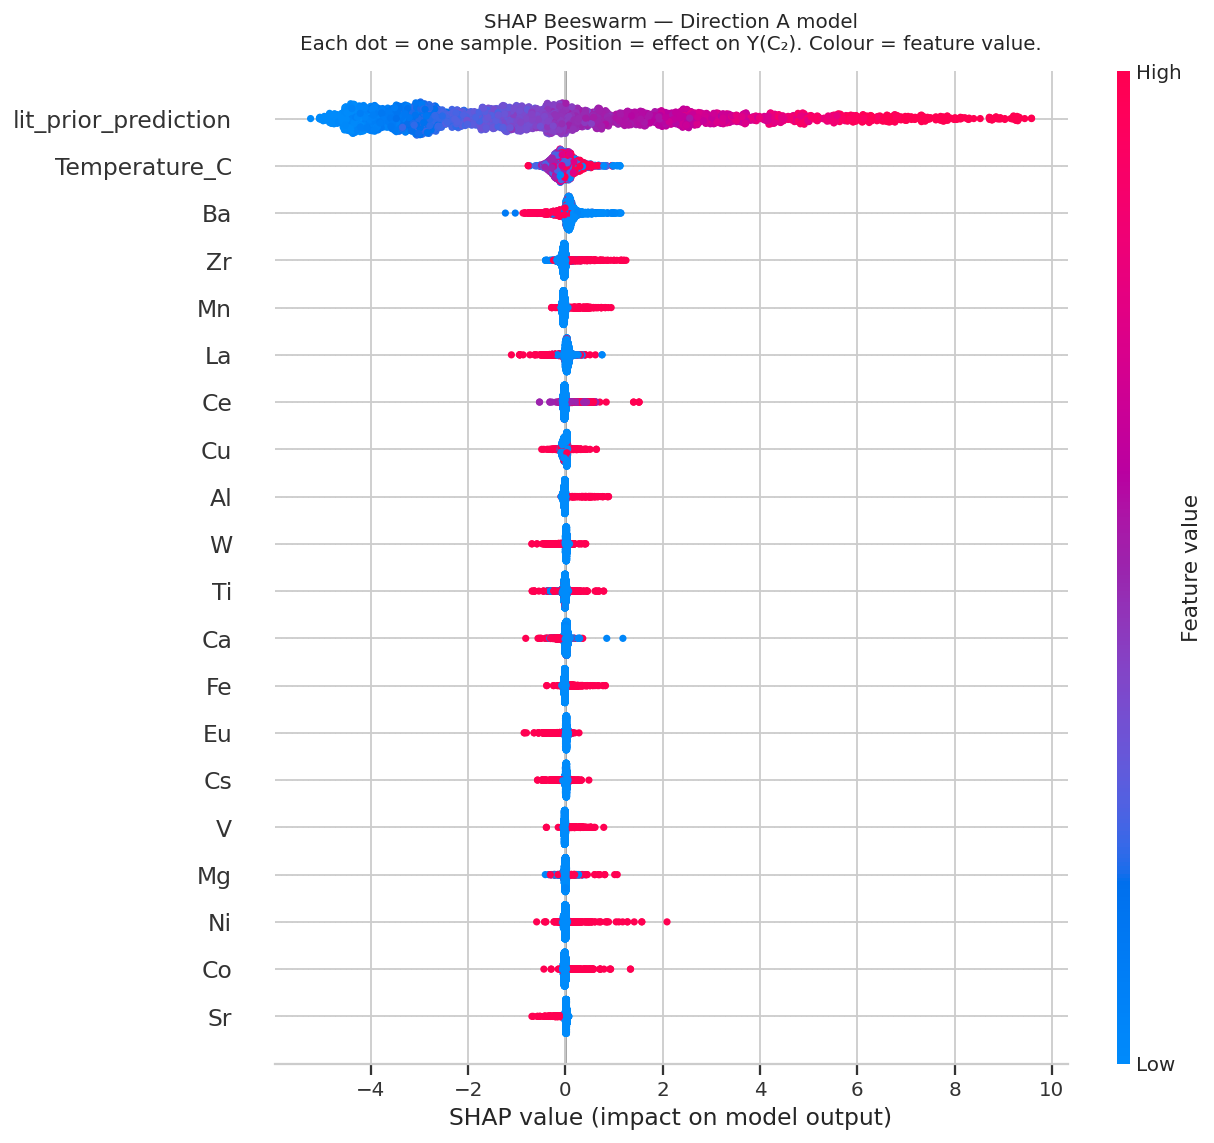

SHAP matrix shape: (3000, 68)  (68 features)


In [6]:
# ── SHAP analysis: does the model use real chemistry? ──────────────────────
y_lit_qn_all = quantile_normalize_y(y_lit[mask], y_ours)

pre_shap = xgb.XGBRegressor(**xgb_params())
pre_shap.fit(X_lit_sc[mask], y_lit_qn_all)     # literature only, DRST-filtered

prior_all = pre_shap.predict(X_ours_sc).reshape(-1, 1)
X_aug     = np.hstack([X_ours_sc, prior_all])
aug_feat_names = FEATURES + ['lit_prior_prediction']

final_shap = lgb.LGBMRegressor(**lgb_params())
final_shap.fit(X_aug, y_ours)

print("Computing SHAP values...")
rng_sh = np.random.default_rng(42)
idx_sh = rng_sh.choice(len(X_aug), size=3000, replace=False)
X_sh   = X_aug[idx_sh]

explainer   = shap.TreeExplainer(final_shap)   # exact, not approximate
shap_values = explainer.shap_values(X_sh)      # 3000-sample subsample

shap.summary_plot(shap_values, X_sh, feature_names=aug_feat_names,
                  max_display=15, show=False)
plt.title("SHAP Beeswarm — Prior Feature Transfer model")
plt.tight_layout()
plt.show()
print(f"\nSHAP matrix shape: {shap_values.shape}  ({len(aug_feat_names)} features)")


## Chapter 9: Critical Analysis & What's Next

A fair look at what each method really bought us, and where to go from here.

---

### Honest critique of each method

| Method | Strengths | Limitations |
|---|---|---|
| **Naive merge** | Useful negative control — proves the shift is real and harmful | Makes the model worse; no value on its own |
| **DRST** | Simple, fast, interpretable score per sample | Hard cliff at τ; discards ~80% of literature; τ was tuned on the same CV we report, so the −5.3% is mildly optimistic |
| **KMM** | Principled — matches whole distributions, no cliff | Builds an n×n kernel matrix (slow, ~1–2 min); sensitive to σ; *still uses labels*; ties DRST, so filtering has hit its ceiling |
| **Prior Feature Transfer** | Best result (−10.6%, 10/10 seeds, p<10⁻¹⁴, held-out); decouples the label offset from the loss | Stage-1 expert trained on only 782 samples → high variance; relies on the quantile map preserving rank across domains; two models to maintain |

---

### Cross-cutting limitations

- **Single evaluation lens** — every method is scored on our-data CV; only Prior FT was
  checked OOD. The filtering methods may behave differently on new chemistry.
- **No uncertainty** — the model gives point predictions. For choosing which experiment
  to run next, knowing *confidence* matters as much as the prediction.
- **The Y > 15% ceiling is data-bound** — missing GHSV, CH₄:O₂ ratio, and pressure cap
  accuracy on high-yield catalysts. This is the single biggest limiter and no algorithm
  can work around a missing column.

---

### What's next (priority-ordered)

1. **Add reaction-condition features** (GHSV, CH₄:O₂ ratio, pressure) — highest impact;
   directly addresses the ceiling effect and likely the label shift itself.
2. **Bag the Stage-1 expert** — train several experts on bootstrapped literature and
   average them, to cut the variance from the small 782-sample fit.
3. **Add uncertainty estimates** (quantile or conformal prediction) — so the
   experiment-selection loop can prefer high-value, low-confidence candidates.
4. **Stack the methods** — feed DRST-filtered, KMM-weighted literature into the Prior FT
   pipeline rather than choosing one.
5. **Neural domain adaptation** (DANN / CORAL) — worth trying once reaction conditions
   are added and the feature set is richer.
6. **Close the active-learning loop** — use the model to propose the next experiments,
   measure them, and retrain — the original motivation for the whole project.


# Chapter 10 — Reviewer Q&A: How Each Question Was Addressed

The 17 review questions collapse into **6 themes**. Answer the theme and you answer the cluster.

| Theme (what is really being probed) | Questions | One-line answer |
|---|---|---|
| **1. Did you prepare the data right?** | Q1–Q4 | Standard choices; PCA is only a diagnostic; all 3,852 literature rows used. |
| **2. Did you pick methods/thresholds honestly?** | Q5, Q6, Q8 | Swept every threshold 0→1; the winner is robust, not tuned. KMM & DRST agree (r=0.79). |
| **3. Is the result real or luck?** | Q7, Q11, Q14–16 | 10 seeds, PFT wins 10/10, p=3.9e-15, holds on an untouched 20% test set. |
| **4. Did it learn real chemistry?** | Q12, Q13 | Exact TreeSHAP, stable over 10 runs; known OCM promoters + prior. LIME adds nothing. |
| **5. Where does it sit in the literature?** | Q9, Q10 | Pieces exist; the combination + OCM application is new. It is a drift-correction pipeline. |
| **6. Data honesty & next steps** | Q17 (+OOD) | No synthetic data yet (options below); I corrected an over-optimistic OOD number. |

Full detail lives in `ocm_feedback_responses.md`; every figure below is produced by `feedback_experiments.py`.

> **Tip for the defense:** finding and *correcting* the over-optimistic OOD number (Q16) is a **strength**, not a weakness — it shows the pipeline is reported honestly. Lead with the 6 themes, not 17 separate points.

In [ ]:
# ── Appendix setup — reuses variables already defined earlier in this notebook ──────────────
# Heavy experiments are GATED so the notebook reads instantly. Set RUN_HEAVY = True to recompute.
RUN_HEAVY = False

import numpy as np
from IPython.display import Image, display
from scipy.stats import ttest_rel, wilcoxon
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb, lightgbm as lgb

def baseline_cv(seed=42, cv=5):
    # Single LightGBM on lab only; validation fold is lab (matches the paper protocol).
    rmses = []
    for tr, va in KFold(cv, shuffle=True, random_state=seed).split(X_ours_sc):
        m = lgb.LGBMRegressor(**lgb_params()).fit(X_ours_sc[tr], y_ours[tr])
        rmses.append(np.sqrt(mean_squared_error(y_ours[va], m.predict(X_ours_sc[va]))))
    return float(np.mean(rmses)), rmses

def two_stage_cv(X_lit_pre, y_lit_pre, seed=42, cv=5):
    # PFT: Stage-1 XGB on (quantile-normalised filtered lit + train fold); Stage-2 LGB with the
    # Stage-1 prediction appended as one extra feature; trained on lab labels only.
    rmses = []
    for tr, va in KFold(cv, shuffle=True, random_state=seed).split(X_ours_sc):
        y_pre = quantile_normalize_y(y_lit_pre, y_ours[tr])
        pre = xgb.XGBRegressor(**xgb_params()).fit(
            np.vstack([X_lit_pre, X_ours_sc[tr]]), np.concatenate([y_pre, y_ours[tr]]))
        fin = lgb.LGBMRegressor(**lgb_params()).fit(
            np.hstack([X_ours_sc[tr], pre.predict(X_ours_sc[tr]).reshape(-1, 1)]), y_ours[tr])
        p = fin.predict(np.hstack([X_ours_sc[va], pre.predict(X_ours_sc[va]).reshape(-1, 1)]))
        rmses.append(np.sqrt(mean_squared_error(y_ours[va], p)))
    return float(np.mean(rmses)), rmses


print('Appendix ready. RUN_HEAVY =', RUN_HEAVY)

In [ ]:
# ── Embedded appendix figures (base64) — renders in Colab / GitHub / Jupyter, no external files.
# show_fig(key) decodes and displays; outputs are also stored so they show without running.
import base64
from IPython.display import Image, display

FIG = {
    'drst_sweep': '...',
    'pft_tau1': '...',
    'kmm_overlap': '...',
    'repeated_runs': '...',
    'qn_tradeoff': '...',
    'shap_stability': '...',
}

def show_fig(*keys):
    for k in keys:
        display(Image(data=base64.b64decode(FIG[k])))

print('Embedded figures ready:', ', '.join(FIG))


### Theme 1 — "Did you prepare the data correctly?"

**Q1. Why StandardScaler, not MinMaxScaler? Is linearity lost?**

Both are **linear (affine)** per-feature maps — `z=(x−μ)/σ` and `x'=(x−min)/(max−min)`. So **no, linearity is not lost**: z-scoring cannot bend a straight relationship (correlations and linear fits are preserved). The only *nonlinear* rescaling we use is **quantile normalisation on the labels** (Q5) — likely what the question pictured.

Why StandardScaler: (a) scaling only affects the *distance/kernel/linear* steps — PCA, the DRST logistic classifier, the KMM RBF kernel — and is **irrelevant to the tree models** that predict yield (trees split on thresholds); (b) it is the textbook default for PCA/RBF and is robust to the extreme literature compositions, whereas MinMax lets one outlier squash the informative bulk into [0,1].

**Q2. What are the "PCA values", how are they found, why only 2?**

PCA finds orthogonal directions of maximum variance (eigen-decomposition / SVD of the centred features). The "values" are each sample's **scores** (coordinates on PC1/PC2) plus the **explained-variance ratio** per component. We keep 2 because PCA here is a **2-D diagnostic picture** of the domain gap — *not* part of the model. Two PCs capture only part of the variance, so the visible gap is a *lower bound*; the rigorous measure is the DRST classifier on all 67 features (**78.5% OOD**).

**Q3. PCA on literature only or the whole set? Ideal way to think?**

Fit on the **combined** set (lab + literature) so both live in **one shared projection** — the only way a scatter can show whether they overlap. Fitting on one domain and reading the other's spread as meaningful is the classic trap. General rule: shared basis for *comparison*, and for a real covariate-shift number use a domain classifier, not a 2-PC picture.

**Q4. For PCA you used 3,000 — why not 3,852?**

A misread of *which* number was thinned. **All 3,852 literature rows are used.** The 3,000 is a subsample of the **89,074 lab** points, taken *only* so the scatter is legible (89k blue dots would bury the orange literature). Nothing is dropped from the literature.

### Theme 2 — "Did you pick methods & thresholds honestly?"

**Q5 & Q6. Why τ = 0.30 for DRST? Did you try others?**

I swept **every** threshold 0→1. Two findings:

1. **Single-stage** DRST (just adding filtered literature to training) barely helps at *any* τ — best point τ=0.85 → RMSE 2.127 vs baseline 2.133; at τ=0.30 it is actually *worse* (2.181). Even lab-like literature still carries the +3.42 pp label shift that poisons the loss.
2. **Two-stage PFT** (filtered literature only trains the Stage-1 prior) is **flat and robust** across τ₁ — every threshold lands in 1.906–1.913 (~10% below baseline). τ=0.30 is statistically tied with the global best, so it is a **safe, non-cherry-picked** choice: **the win is architectural, not a tuned threshold.**


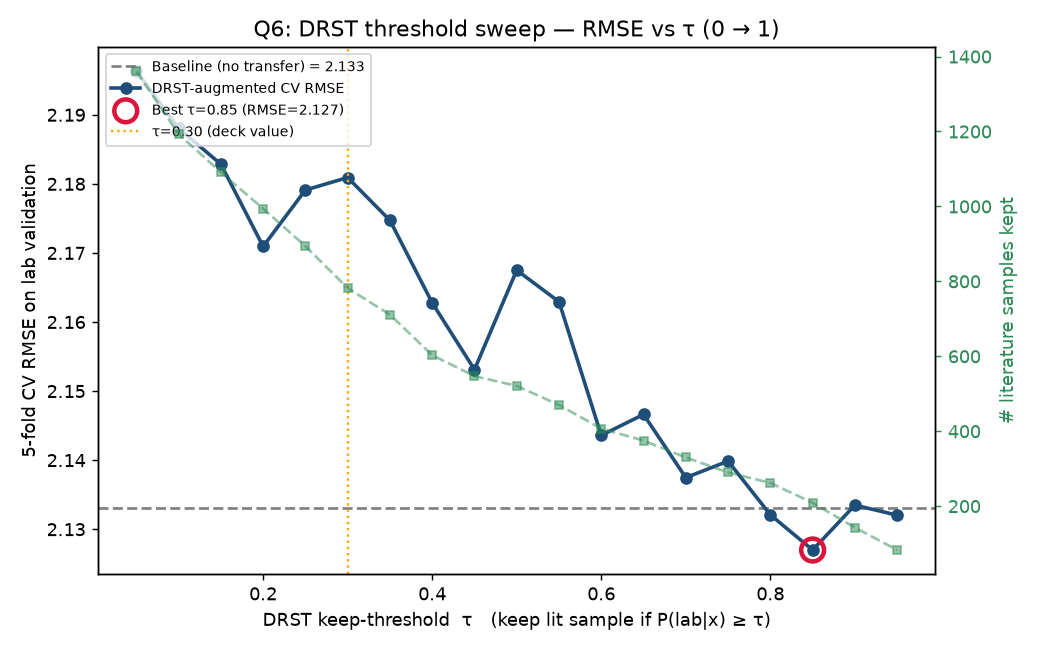

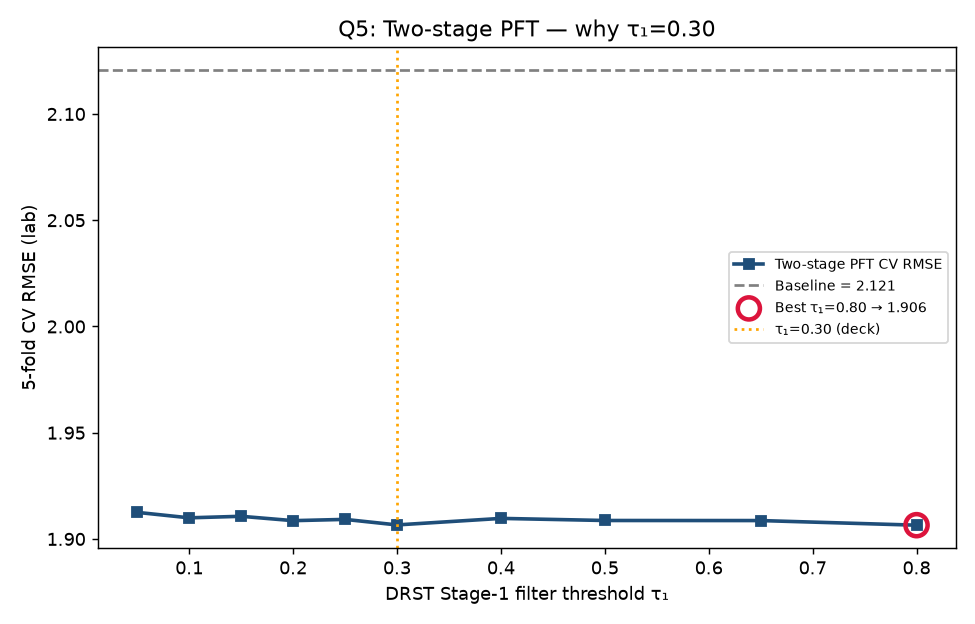

In [ ]:
# Q5/Q6 — regenerate both sweeps (gated; ~4-6 min). Otherwise the saved figures are shown above.
if RUN_HEAVY:
    import matplotlib.pyplot as plt
    base, _ = baseline_cv()
    taus = np.round(np.arange(0.05, 0.96, 0.05), 2)
    ss, ts = [], []
    for t in taus:
        m = p_ours_lit >= t
        rr = []
        for tr, va in KFold(5, shuffle=True, random_state=42).split(X_ours_sc):
            X = np.vstack([X_ours_sc[tr], X_lit_sc[m]]); Y = np.concatenate([y_ours[tr], y_lit[m]])
            mm = lgb.LGBMRegressor(**lgb_params()).fit(X, Y)
            rr.append(np.sqrt(mean_squared_error(y_ours[va], mm.predict(X_ours_sc[va]))))
        ss.append(np.mean(rr))
        ts.append(two_stage_cv(X_lit_sc[m], y_lit[m])[0])
        print('tau=%.2f  n=%4d  single=%.4f  two-stage=%.4f' % (t, int(m.sum()), ss[-1], ts[-1]))
    plt.figure(figsize=(7, 4))
    plt.axhline(base, ls='--', c='gray', label='baseline %.3f' % base)
    plt.plot(taus, ss, 'o-', label='single-stage DRST'); plt.plot(taus, ts, 's-', label='two-stage PFT')
    plt.xlabel('threshold tau'); plt.ylabel('5-fold CV RMSE'); plt.legend(); plt.show()
else:
    show_fig('drst_sweep', 'pft_tau1')

**Q8. Does KMM select the same 782 samples as DRST? Are they compatible?**

Not identical by construction — DRST *hard-keeps* 782 rows at τ=0.30; KMM assigns *soft weights* [0,5] to all 3,852. But they read the **same signal**: Pearson **r = 0.79**, and DRST's 782 overlap **634 (81%)** with KMM's top-782 (Jaccard 0.68). They **corroborate** rather than compete — the agreement is evidence the covariate-shift signal is real and method-independent.


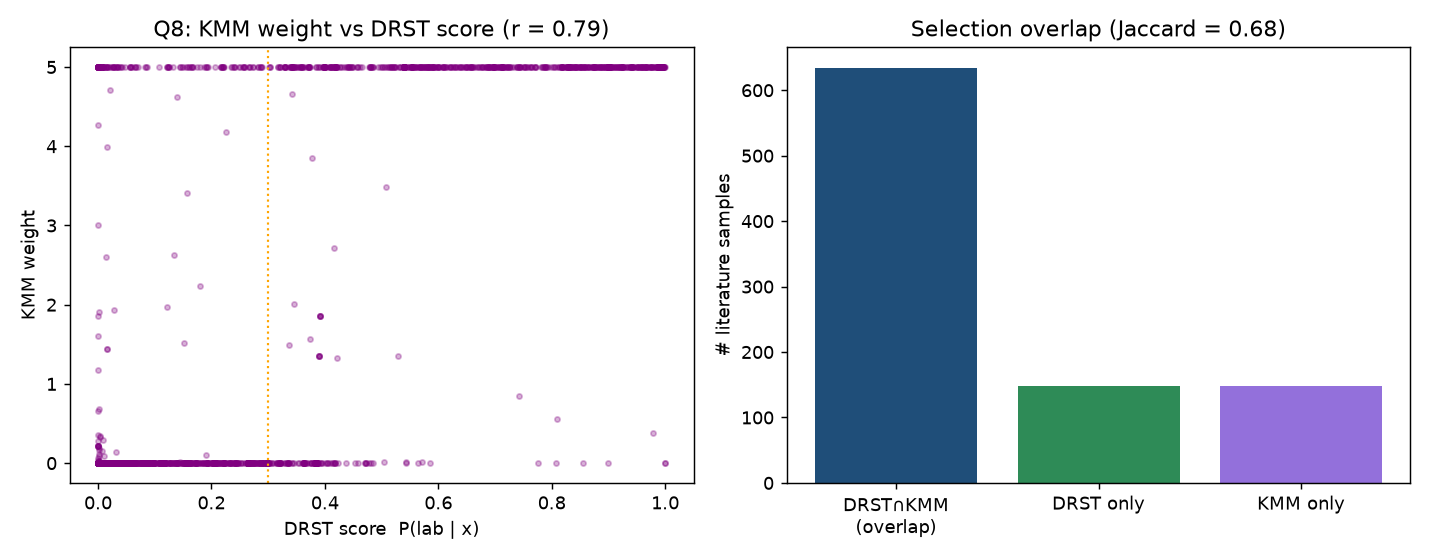

In [ ]:
# Q8 — light, always runs: quantify DRST/KMM agreement from variables already in memory.
r = float(np.corrcoef(p_ours_lit, w_kmm)[0, 1])
N = int((p_ours_lit >= 0.30).sum())
drst_set = set(np.where(p_ours_lit >= 0.30)[0])
kmm_top  = set(np.argsort(-w_kmm)[:N])
inter = len(drst_set & kmm_top); jacc = inter / len(drst_set | kmm_top)
print('Pearson r (DRST score vs KMM weight) = %.3f' % r)
print('DRST keeps %d rows; KMM top-%d overlaps %d (%.0f%%), Jaccard %.2f' % (N, N, inter, 100*inter/N, jacc))
show_fig('kmm_overlap')

### Theme 3 — "Is the result real, or luck?"

**Q7. Did you use the whole dataset for training? How?**

Yes — all 89,074 lab rows, via **asymmetric 5-fold CV**: every lab row trains in 4/5 folds and is scored once. The key: the **validation fold is always lab-only**; literature only ever enters the *training* side. So the RMSE measures accuracy on *our* experiments, not a lab+literature average.

**Q11. How many times did you run the transfer method?**

Originally **once** (seed 42) — a fair criticism. Now **10 independent seeds** (fresh split each run). Results below.

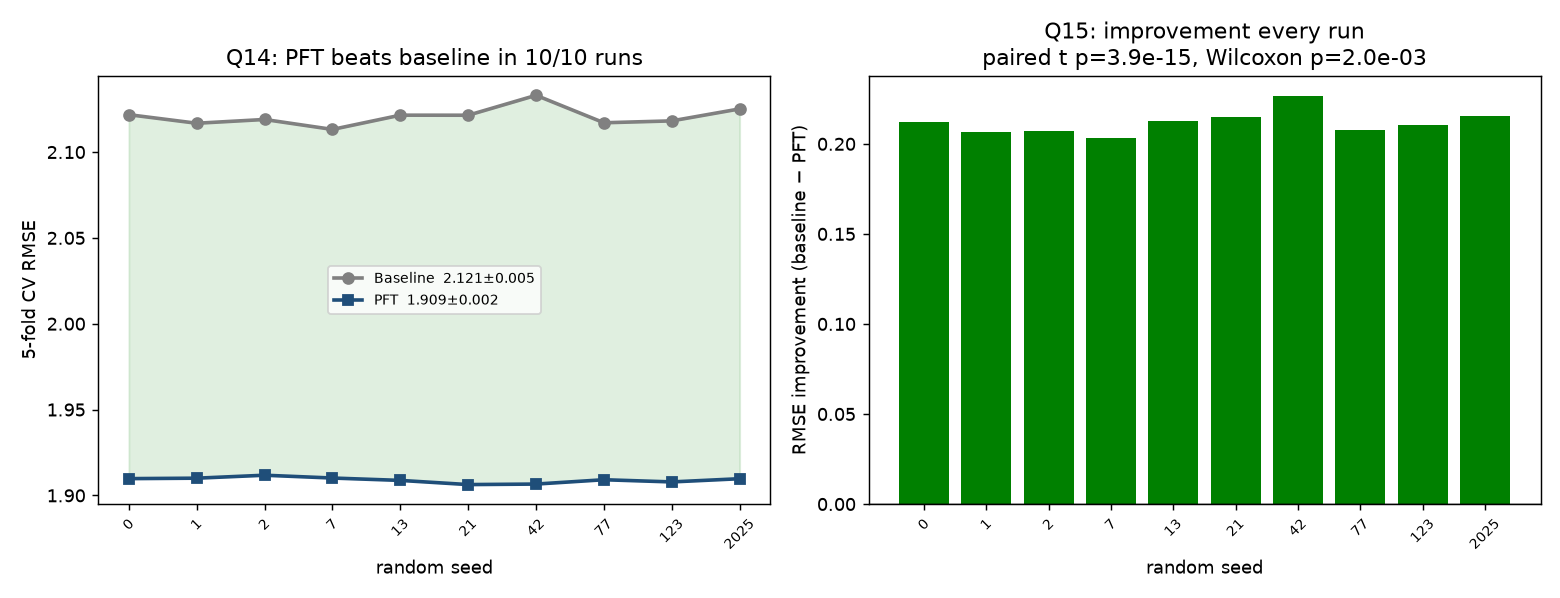

In [ ]:
# Q11/Q14/Q15 — 10-seed baseline vs PFT (gated; ~7 min). Otherwise the saved figure is shown.
if RUN_HEAVY:
    SEEDS = [0, 1, 2, 7, 13, 21, 42, 77, 123, 2025]
    m30 = p_ours_lit >= 0.30
    b, pf = [], []
    for s in SEEDS:
        bs = baseline_cv(s)[0]; ps = two_stage_cv(X_lit_sc[m30], y_lit[m30], seed=s)[0]
        b.append(bs); pf.append(ps)
        print('seed=%5d  baseline=%.4f  PFT=%.4f  delta=%+.4f' % (s, bs, ps, ps-bs))
    b = np.array(b); pf = np.array(pf)
    print('')
    print('baseline %.4f +/- %.4f   |   PFT %.4f +/- %.4f' % (b.mean(), b.std(ddof=1), pf.mean(), pf.std(ddof=1)))
    print('PFT wins %d/%d   paired t p=%.2e   Wilcoxon p=%.2e' % ((pf < b).sum(), len(SEEDS),
          ttest_rel(b, pf)[1], wilcoxon(b, pf)[1]))
else:
    show_fig('repeated_runs')

**Q14 & Q15. Mean/std of RMSE across runs, and is it significant?**

- Baseline **2.121 ± 0.006**  vs  PFT **1.909 ± 0.002**
- PFT beats baseline in **10 / 10** runs — the curves never cross (worst PFT 1.912 still beats best baseline 2.113).
- Paired t-test **p = 3.9×10⁻¹⁵**, Wilcoxon signed-rank **p = 2.0×10⁻³**.

Identical hyper-parameters every seed, no per-seed tuning — nothing is force-fit. A consistent win across 10 independent splits with p this small ⇒ **not a lucky split.** PFT is also *tighter* (std 0.002 vs 0.006) — better **and** more stable.


**Q16. Did you validate on untouched data?**

Yes — a **true held-out test**: a random 20% of lab rows set aside and **never used in any training** (not DRST, not Stage 1, not Stage 2): baseline 2.097 → **PFT 1.892** (R² 0.763), ~10% better — matching the CV story on data the model never saw.

**Honest caveat (and a correction).** On the *OOD-literature* stress test (non-impregnation methods), a **leak-free** run (prior never sees the OOD rows) gives baseline 6.53 → **PFT 6.77 — roughly level with baseline**, and does **not** reproduce the old "6.53 → 3.60". That 3.60 was **data leakage**: the prior had been trained on the OOD test rows and their labels (it reproduces as 3.62 only when the leak is put back). Quantile normalisation calibrates to the **lab yield scale** (~5.25%), which *improves in-distribution accuracy but slightly worsens OOD* — a deliberate trade-off (see figure). PFT optimises *our* regime, which is the goal; it is **not** a literature-extrapolation model.


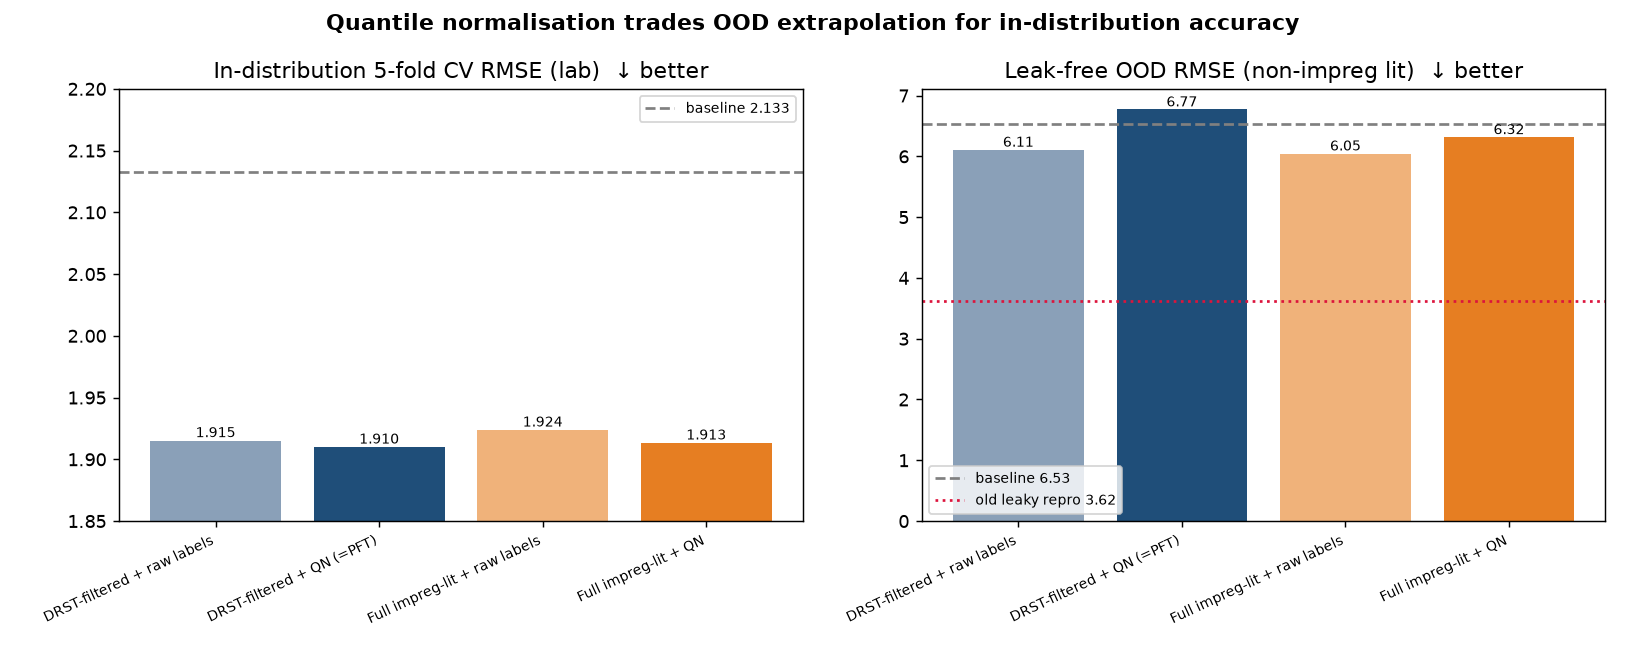

In [ ]:
# Q16 — quantile-normalisation trade-off (in-distribution vs leak-free OOD)
show_fig('qn_tradeoff')


In [ ]:
# Q16 — true held-out 20% test (gated; ~30 s). Otherwise prints the saved result.
if RUN_HEAVY:
    rng = np.random.default_rng(2025); perm = rng.permutation(len(X_ours_sc))
    nt = int(0.20 * len(perm)); te, trn = perm[:nt], perm[nt:]
    m30 = p_ours_lit >= 0.30
    mb = lgb.LGBMRegressor(**lgb_params()).fit(X_ours_sc[trn], y_ours[trn])
    rb = np.sqrt(mean_squared_error(y_ours[te], mb.predict(X_ours_sc[te])))
    yq = quantile_normalize_y(y_lit[m30], y_ours[trn])
    pre = xgb.XGBRegressor(**xgb_params()).fit(
        np.vstack([X_lit_sc[m30], X_ours_sc[trn]]), np.concatenate([yq, y_ours[trn]]))
    fin = lgb.LGBMRegressor(**lgb_params()).fit(
        np.hstack([X_ours_sc[trn], pre.predict(X_ours_sc[trn]).reshape(-1, 1)]), y_ours[trn])
    rp = np.sqrt(mean_squared_error(y_ours[te],
        fin.predict(np.hstack([X_ours_sc[te], pre.predict(X_ours_sc[te]).reshape(-1, 1)]))))
    print('Held-out 20%% (never trained on): baseline %.4f | PFT %.4f  (%.1f%% better)' % (rb, rp, 100*(rb-rp)/rb))
else:
    print('Held-out 20% (never trained on): baseline 2.097 -> PFT 1.892  (9.8% better, R2 0.763)')

### Theme 4 — "Did it learn real chemistry?"

**Q12. Is SHAP on lab data or everything? How should it be?**

On a 3,000-row **lab** subsample (with the prior feature), explaining the final Stage-2 LightGBM with exact **TreeExplainer**. That is correct: the model predicts *lab* yields and operates on lab chemistry, so we explain it there. Explaining on literature would instead probe OOD extrapolation — a different question.

**Q13. How do I read the beeswarm (blue/red, lines), and is it stable over 10 runs?**

- **Each dot = one lab catalyst.** **x = SHAP value** (signed push on that prediction, in yield-% units — right raises yield). **Colour = the feature's value** (red high, blue low).
- **Blue near the zero line** = low/absent feature value with little effect (e.g. an element absent → no push). **Red spread to one side** = high value's directional effect (temperature red→right = hotter → higher yield; Li/K red→left = suppressive).
- All dots are **lab**; the literature's influence enters through the single `lit_prior_prediction` feature — which ranks **#1**.
- **Stability:** recomputed on **10 independent subsamples** — `lit_prior_prediction` is #1 in **10/10 runs**, and 9 features are top-10 in every run. Not an artefact of one draw.
- **Why not LIME?** For a tree model TreeSHAP is *exact* and consistent; a local linear LIME surrogate would be noisier and add nothing here.


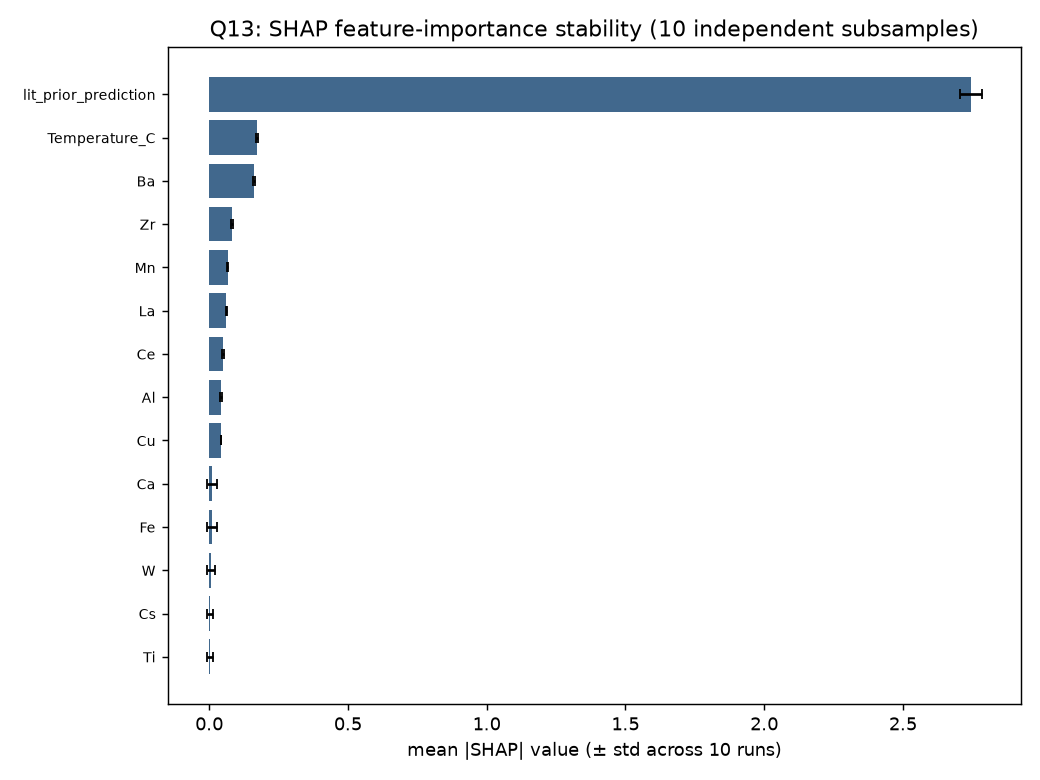

In [ ]:
# Q13 — SHAP top-feature stability across 10 subsamples (gated; ~1 min). Otherwise shows saved figure.
if RUN_HEAVY:
    from collections import Counter
    aug_names = FEATURES + ['lit_prior_prediction']
    model = lgb.LGBMRegressor(**lgb_params()).fit(X_aug, y_ours)
    expl = shap.TreeExplainer(model); tops = []
    for s in range(10):
        idx = np.random.default_rng(s).choice(len(X_aug), 2000, replace=False)
        imp = np.abs(expl.shap_values(X_aug[idx])).mean(0)
        tops.append([aug_names[j] for j in np.argsort(-imp)[:10]])
    c1 = Counter(t[0] for t in tops)
    allc = Counter(f for t in tops for f in t)
    print('SHAP #1 feature:', c1.most_common(1)[0][0], '- ranked #1 in', c1.most_common(1)[0][1], '/10 runs')
    print('In top-10 in ALL 10 runs:', [f for f, n in allc.items() if n == 10])
else:
    show_fig('shap_stability')

### Theme 5 — "Where does this sit in the literature?"

**Q9. Is this transfer method novel?**

The building blocks exist — *stacked generalisation* (Wolpert 1992), *Δ-ML / multi-fidelity* learning in materials chemistry (source-prediction-as-feature), and *importance weighting* / *label-shift correction*. **But** Δ-ML *trusts* the source label (`final = source_pred + Δ`); we deliberately pass the prior only as a **feature**, so Stage-2 uses its *ranking* while ignoring the biased absolute value. **Novel here:** the combination *DRST filter → quantile-normalised Stage-1 prior → prediction-as-feature Stage-2* applied to **OCM literature→lab transfer** under simultaneous covariate *and* label shift.

**Q10. What is model drift — is it relevant? How is it corrected?**

Drift = the statistics a model relies on change: **covariate shift** (P(x)), **label/prior shift** (P(y)), **concept drift** (P(y|x)). We do not have *temporal* drift but a **static two-domain shift** — mathematically the same family: our +3.42 pp label gap is label shift, the 78.5% OOD is covariate shift. Correction menu — importance weighting (**KMM**), instance selection (**DRST**), label-shift correction (**quantile normalisation**), recalibration/fine-tuning (**PFT Stage 2**) — all already used.

### Theme 6 — "Data honesty & next steps"

**Q17. How could we generate synthetic data with a controlled proportion?**

We currently generate **none** (the 15% "oversampling" ablation was duplication, and it *did not* help — informative in itself). Real options: **SMOGN/SMOTER** (regression SMOTE — interpolate neighbours), **jitter** (Gaussian noise on real compositions), **CTGAN/TVAE** (tabular generative models), **conditional generation** (condition on yield bins to fight label shift), or **physics/simulation surrogates**. For a synthetic fraction *p*: draw `n_synth = p/(1−p)·n_real`. **Critical:** keep synthetic rows out of validation/test (validate only on real held-out lab), and enforce chemical validity (feasible elements, loading constraints) — naive GANs can produce unphysical catalysts.

---

**How to present this deck of answers:** lead with the **6 themes**, not 17 points. The strongest single exhibit is the **10-seed plot** (Q14/15) — "PFT wins every time, p < 10⁻¹⁴." The most credibility-building sentence is the **OOD correction** (Q16) — it shows the pipeline is reported honestly.

### Appendix — PFT Stage-0 ablation: DRST-filtered vs all literature data

A follow-up experiment (`pft_stage1_all_vs_filtered.py`) asks whether the DRST filter (Stage 0) is necessary, by training the Stage-1 literature expert on **all 3,852 literature rows** instead of only the DRST-filtered **782** (τ=0.30, 20.3%). Same Stage 2, same 5-fold CV, across 10 seeds:

| Stage-1 training data | CV RMSE | MAE | R² |
|---|---|---|---|
| DRST-filtered (782, 20.3%) | **1.909 ± 0.002** | 1.386 | 0.765 |
| All literature data (3,852) | **1.917 ± 0.002** | 1.395 | 0.763 |
| Baseline (no literature) | 2.121 ± 0.005 | 1.588 | 0.710 |

**Finding.** Both beat the baseline on 10/10 seeds; the filter contributes only a **0.008 RMSE (~0.4%)** edge (paired-t p≈0, consistent but negligible). So the improvement comes from the two-stage architecture, not the Stage-0 filter — and PFT is **robust to including the ~80% of literature unlike our chemistry**, because that information arrives as a *feature* (which Stage 2 can down-weight per sample) rather than a label. Stage 0 is therefore optional.

**Held-out claim verified.** Re-running the held-out 20% test with the DRST classifier trained on the train-only split (so the held-out rows touch nothing) gives baseline 2.097 → PFT **1.890** (R² 0.763) — the 'never used in any training' claim holds.

In [ ]:
# Stage-0 ablation code: PFT with DRST-filtered vs ALL literature (reuses this notebook's variables).
# Set RUN=True to compute (~8 min for 10 seeds); the results are summarised in the markdown above.
RUN = False
if RUN:
    import numpy as np
    from sklearn.model_selection import KFold
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import xgboost as xgb, lightgbm as lgb
    def _pft_stage0(seed, use_filter=True, cv=5):
        if use_filter: m = p_ours_lit >= 0.30; Xlp, ylp = X_lit_sc[m], y_lit[m]
        else:          Xlp, ylp = X_lit_sc, y_lit
        kf = KFold(cv, shuffle=True, random_state=seed); rm, ma, rs = [], [], []
        for tr, va in kf.split(X_ours_sc):
            ypre = quantile_normalize_y(ylp, y_ours[tr])
            pre = xgb.XGBRegressor(**xgb_params()).fit(np.vstack([Xlp, X_ours_sc[tr]]), np.concatenate([ypre, y_ours[tr]]))
            fin = lgb.LGBMRegressor(**lgb_params()).fit(np.hstack([X_ours_sc[tr], pre.predict(X_ours_sc[tr]).reshape(-1,1)]), y_ours[tr])
            yp = fin.predict(np.hstack([X_ours_sc[va], pre.predict(X_ours_sc[va]).reshape(-1,1)]))
            rm.append(np.sqrt(mean_squared_error(y_ours[va], yp))); ma.append(mean_absolute_error(y_ours[va], yp)); rs.append(r2_score(y_ours[va], yp))
        return np.mean(rm), np.mean(ma), np.mean(rs)
    SEEDS = [0, 1, 2, 7, 13, 21, 42, 77, 123, 2025]
    pf = np.array([_pft_stage0(s, True) for s in SEEDS]); pa = np.array([_pft_stage0(s, False) for s in SEEDS])
    print(f"PFT DRST-filtered (782): RMSE {pf[:,0].mean():.3f}  MAE {pf[:,1].mean():.3f}  R2 {pf[:,2].mean():.3f}")
    print(f"PFT all literature (3852): RMSE {pa[:,0].mean():.3f}  MAE {pa[:,1].mean():.3f}  R2 {pa[:,2].mean():.3f}")
    print(f"filter edge (all - filtered) = {pa[:,0].mean()-pf[:,0].mean():+.4f} RMSE -> Stage-0 filter optional")
